In [1]:
# goal: profile the data, gather some initial features

from fx import *  # my helper functions

In [2]:
#1. get a list of files
files = list(Path('/mnt/4C74F47B74F468DA/Pictures').glob('**/*.JPG'))
print('# files=',len(files))
files += list(Path('/mnt/4C74F47B74F468DA/DCIM').glob('**/*.JPG'))
print('# files=',len(files))
files[:5]

# files= 12760
# files= 13652


[PosixPath('/mnt/4C74F47B74F468DA/Pictures/BKUU7461-2020-11-04 233155.JPG'),
 PosixPath('/mnt/4C74F47B74F468DA/Pictures/BORE1037-2018-10-11 001716.JPG'),
 PosixPath('/mnt/4C74F47B74F468DA/Pictures/BVHR0380-2021-10-05 213751.JPG'),
 PosixPath('/mnt/4C74F47B74F468DA/Pictures/CWII4264-2020-11-04 234258.JPG'),
 PosixPath('/mnt/4C74F47B74F468DA/Pictures/DFCN3364-2021-08-24 221724.JPG')]

In [7]:
# extract & save file stats

def file_size(file):
    return os.stat(file).st_size
 
def file_dt(file):
    # m(odified) is earliest i can find
    # b(irth)time n/a
    # c(hanged) time and a(ccessed) time are more recent
    ts = os.stat(file).st_mtime
    return datetime.datetime.fromtimestamp(ts)

df = (
    pd.DataFrame({'path':[str(f) for f in files[:]]})
    .add_col(sz_bytes=lambda x: file_size(x.path))
    .add_col(file_ts=lambda x: file_dt(x.path))
)

df.print_shape().to_parquet('features/files.parquet',index=False)
assert(df.get_dupes('path').shape[0]==0)  # ensure no duplicate records
df.head()

(13652, 3)


,path,sz_bytes,file_ts
0,/mnt/4C74F47B74F468DA/Pictures/BKUU7461-2020-1...,756288,2020-11-04 17:31:55
1,/mnt/4C74F47B74F468DA/Pictures/BORE1037-2018-1...,229622,2018-10-10 19:17:16
2,/mnt/4C74F47B74F468DA/Pictures/BVHR0380-2021-1...,291883,2021-10-05 16:37:51
3,/mnt/4C74F47B74F468DA/Pictures/CWII4264-2020-1...,584288,2020-11-04 17:42:58
4,/mnt/4C74F47B74F468DA/Pictures/DFCN3364-2021-0...,1343071,2021-08-24 17:17:24


In [8]:
# extract and save image metadata: 
    # datetime photo was taken
    # latitude longitute for some

df = (
    df
    # .sample(50)
    .assign(img_dt=lambda x: [get_exif(p)[0] for p in x.path])
    .assign(img_lat=lambda x: [get_exif(p)[1] for p in x.path])
    .assign(img_lng=lambda x: [get_exif(p)[2] for p in x.path])
    # .print_cols()
)

df[['path', 'img_dt', 'img_lat', 'img_lng']].print_shape().to_parquet('features/exif.parquet',index=False)
assert(df.get_dupes('path').shape[0]==0)  # ensure no duplicate records
df.head()

(13652, 4)


,path,sz_bytes,file_ts,img_dt,img_lat,img_lng
0,/mnt/4C74F47B74F468DA/Pictures/BKUU7461-2020-1...,756288,2020-11-04 17:31:55,2020-11-04 17:27:43,NaN,NaN
1,/mnt/4C74F47B74F468DA/Pictures/BORE1037-2018-1...,229622,2018-10-10 19:17:16,NaT,NaN,NaN
2,/mnt/4C74F47B74F468DA/Pictures/BVHR0380-2021-1...,291883,2021-10-05 16:37:51,2021-10-02 17:55:15,NaN,NaN
3,/mnt/4C74F47B74F468DA/Pictures/CWII4264-2020-1...,584288,2020-11-04 17:42:58,2020-11-04 17:32:26,NaN,NaN
4,/mnt/4C74F47B74F468DA/Pictures/DFCN3364-2021-0...,1343071,2021-08-24 17:17:24,2021-03-04 14:23:35,NaN,NaN


In [9]:
(
    df
    .assign(has_date=lambda x: x.img_dt == x.img_dt)
    .has_date.value_counts()  
)

True     13427
False      225
Name: has_date, dtype: int64

pandas._libs.tslibs.timestamps.Timestamp

<Axes: xlabel='img_dt'>

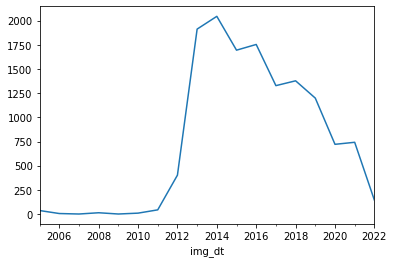

In [11]:
(
    df
    .query(''' img_dt==img_dt ''')
    .set_index('img_dt').resample('Y')['path'].count().plot()
)

In [12]:
(
    df
    .assign(has_latlong=lambda x: x.img_lat == x.img_lat)
    .has_latlong.value_counts()  
)

False    10111
True      3541
Name: has_latlong, dtype: int64